In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv", encoding="latin1")

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (27481, 10)

Column names:
['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

First 5 rows:


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Duplicate rows:
0


In [4]:
sentiment_counts = df["sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


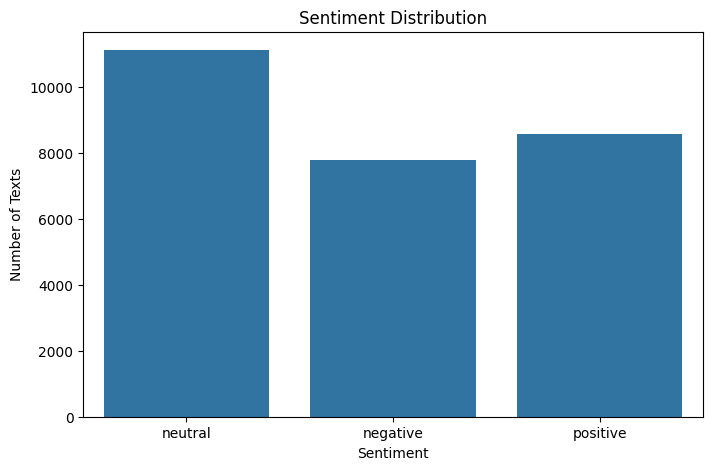

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.show()

In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("Original Text:")
print(df["text"].iloc[0])

print("\nCleaned Text:")
print(df["clean_text"].iloc[0])

Original Text:
 I`d have responded, if I were going

Cleaned Text:
id have responded if i were going


In [7]:
df["text_length"] = df["clean_text"].str.len()

avg_length = df.groupby("sentiment")["text_length"].mean()

print("Average Text Length by Sentiment:")
print(avg_length)

Average Text Length by Sentiment:
sentiment
negative    64.475774
neutral     58.902321
positive    63.922279
Name: text_length, dtype: float64


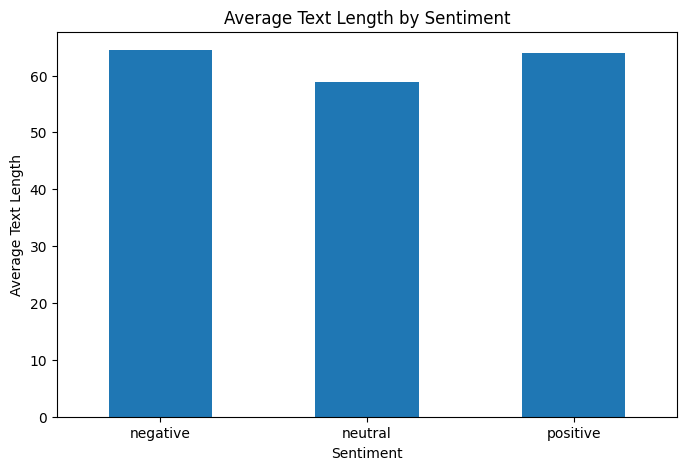

In [8]:
plt.figure(figsize=(8,5))

avg_length.plot(kind="bar")

plt.title("Average Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Text Length")
plt.xticks(rotation=0)
plt.show()

In [9]:
time_sentiment = pd.crosstab(
    df["Time of Tweet"],
    df["sentiment"],
    normalize="index"
) * 100

print("Sentiment Percentage by Time of Tweet:")
print(time_sentiment.round(2))

Sentiment Percentage by Time of Tweet:
sentiment      negative  neutral  positive
Time of Tweet                             
morning           27.96    41.08     30.97
night             28.58    40.17     31.24
noon              28.41    40.12     31.47


<Figure size 800x500 with 0 Axes>

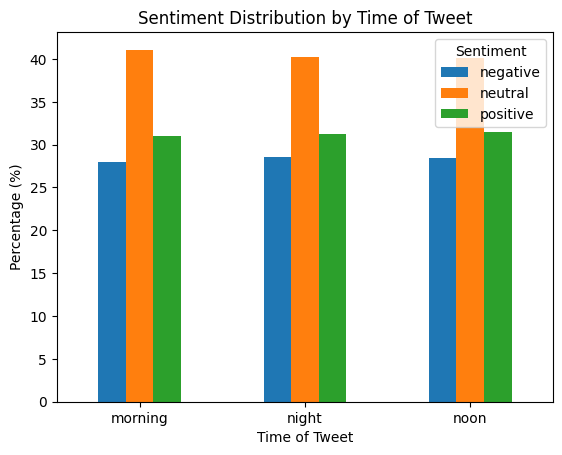

In [10]:
plt.figure(figsize=(8,5))

time_sentiment.plot(kind="bar")

plt.title("Sentiment Distribution by Time of Tweet")
plt.xlabel("Time of Tweet")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

In [11]:
age_sentiment = pd.crosstab(
    df["Age of User"],
    df["sentiment"],
    normalize="index"
) * 100

print("Sentiment Percentage by Age Group:")
print(age_sentiment.round(2))

Sentiment Percentage by Age Group:
sentiment    negative  neutral  positive
Age of User                             
0-20            28.16    41.43     30.41
21-30           29.17    39.96     30.87
31-45           28.71    39.61     31.68
46-60           27.75    40.72     31.53
60-70           27.64    40.28     32.07
70-100          28.45    40.74     30.81


<Figure size 1000x600 with 0 Axes>

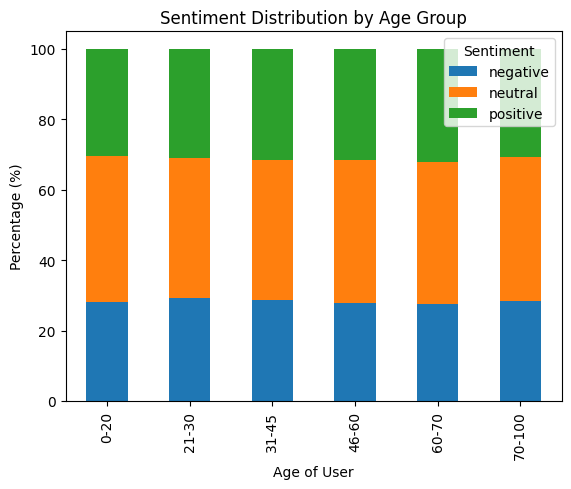

In [12]:
plt.figure(figsize=(10,6))

age_sentiment.plot(kind="bar", stacked=True)

plt.title("Sentiment Distribution by Age Group")
plt.xlabel("Age of User")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.show()

## Key Insights

1. The dataset contains 27,481 records and 10 columns.
2. The dataset contains text-based information along with sentiment labels.
3. Missing values and duplicate records were checked as part of data quality analysis.
4. Sentiment distribution was analyzed to understand the proportion of different sentiment categories.
5. Text cleaning was performed by removing URLs, mentions, hashtags, special characters, and unnecessary spaces.
6. Average text length was compared across different sentiment categories.
7. Sentiment distribution was also analyzed across different times of the day.
8. Sentiment patterns were further explored across different user age groups.

## Conclusion

The Sentiment Analysis project provided an overview of sentiment patterns in the dataset.

The analysis included data quality checking, text cleaning, sentiment distribution,
text length analysis, time-based sentiment analysis, and age-based sentiment analysis.

The visualizations helped make the sentiment patterns easier to understand and provided
useful insights from the available text and user information.